<a href="https://colab.research.google.com/github/Eliezer-Carvalho/IP/blob/master/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **[Hugging Face](https://huggingface.co/)**

Plataforma padrão na indústria para modelos de Inteligência Artificial. <br>
Foi a plataforma usada para o download dos modelos. <br>

O código seguinte foi rodado tanto em CPU como em GPU.

## Carregar Modelos

In [ ]:
#### Carregar Modelos ####
### Duas Opções -> Upload Local ou Upload via Hugging Face
### Como o objetivo é hospedar um modelo local foi feito o download do modelo para o ambiente pessoal para começar desde cedo a estabelecer algumas boas práticas.
### Este processo acarreta custos de memória e no caso de treino na GPU (via Google Colab) é dispendioso em termos de tempo dar upload do modelo no ecossistema Google.

#Libraries
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

MODELO_NAME = "x" #Se for via HF usar o nome do modelo
MODELO_PATH = "x" #Se for via ambiente pessoal é meter o caminho que indica a pasta

modelo = AutoModelForCausalLM.from_pretrained (MODELO_PATH, device_map = "auto") #device_map pode ser "cpu" ou "cuda"

tokenizer = AutoTokenizer.from_pretrained (MODELO_PATH) #load do tokenizer do modelo, importante para prompt processing e token generation

c:\Users\eliez\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


KeyboardInterrupt: 

## Inferência dos Modelos

In [ ]:
#### Inferência ####
#### A Inferência pode ser um processo bem mais trabalhado (top_k, top_p, etc) mas aqui está uma versão simples.

input = tokenizer (prompt, return_tensor = "pt") #return_tensor = pytorch

probs = modelo (**input)

tokens = modelo.generate (**input, max_new_tokens = x) #** desfaz dict

texto = tokenizer.decode (tokens[0]) #token a token

# **[llama.cpp](https://github.com/ggml-org/llama.cpp)**

É uma ferramenta que permite realizar inferência de maneira prática e eficiente na CPU. <br>
Em CPU llama.cpp é o que domina.

In [ ]:
#### llama.cpp não é como uma biblioteca em Python, é mais uma ferramenta que permite executar comandos no terminal ####
#### Alguns dos comandos importantes:

convert_hf_to_gguf.py	-> Comando que converte o formato de ficheiro para GGUF (formato de ficheiro excelente para correr modelos na CPU)

llama-bench -> Permite realizar métricas de benchmark no modelo e descobrir o valor de Prompt Processing/s e Token Generation/s

llama-quantize -> Permite aplicar Quantização a um modelo

llama-cli -> Chat Mode (-c, -t, -b, --temp, --top_k, --top_p, -n)

llama-server -> Lança um servidor estilo OpenAI

# **Quantização**

Quantização tem como objetivo converter o tipo de dados do modelo para um tipo mais pequeno em termos de memória. <br>
Existe uma ferramenta para CPU e outra para GPU.

## CPU

In [ ]:
llama-quantize -> Permite aplicar Quantização a um modelo

## GPU

In [ ]:
#### Foi utilizada a biblioteca BitsandBytes da Hugging Face ####

from transformers import BitsAndBytesConfig

quantization = BitsAndBytesConfig (
    load_in_4bit = True,  #Quantização
    bnb_4bit_quant_type = 'nf4',  #Tipo de Quantização
    bnb_4bit_use_double_quant = True, #Double Quantization
    bnb_4bit_compute_dtype = 'float16', #Tipo de precisão usada nos cálculos durante a inferência.
)

modelo = AutoModelForCausalLM.from_pretrained (MODELO_PATH, device_map = 'auto', quantization_config = quantization)

tokenizer = AutoTokenizer.from_pretrained (MODELO_PATH)

modelo.save_pretrained ('/Modelos')
tokenizer.save_pretrained ('/Modelos')

# **CPU vs CPU (llama.cpp) vs GPU**

Este estudo foi realizado em 10 runs em que cada modelo gerou 100 tokens. <br>
Foram somados os segundos e divididos depois pelo número de tokens totais (no total das 10 runs). <br>


$$
\text {tokens/s} = \frac{\text{Número de Tokens}}{\text{Tempo}}
$$

In [ ]:
import torch
import time

device = 'cuda' if torch.cuda.is_available() else 'cpu' #GPU -> CUDA | CPU -> normal

modelo = AutoModelForCausalLM.from_pretrained (MODELO_PATH).to(device)

tokenizer = AutoTokenizer.from_pretrained (MODELO_PATH)

for i in range (10):
  inputs = tokenizer (prompt, return_tensors = 'pt').to(device)
  #print (inputs['inputs_id'].shape()) #Para ver número de tokens processados

  ####### Prompt Processing
  torch.cuda.synchronize() #Só se usa se for CUDA, sicroniza com a GPU
  start_pp = time.time()

  with torch.no_grad():
    probs = MODEL (**inputs) #Prompt Processing

  torch.cuda.synchronize() #Só se usa se for CUDA, sicroniza com a GPU
  end_pp = time.time()
  ################################


  ######## Token Generation
  torch.cuda.synchronize() #Só se usa se for CUDA, sicroniza com a GPU
  start_tp = time.time()

  output_tokens = MODEL.generate (**inputs, max_new_tokens = 100) #Token Generation

  torch.cuda.synchronize() #Só se usa se for CUDA, sicroniza com a GPU
  end_tp = time.time()
  #####################################

  text = tokenizer.decode (output_tokens [0])
  print (text)

  elapsed_time_pp = end_pp - start_pp #tempo total = terminou - começou
  elapsed_time_tp = end_tp - start_tp

  return elapsed_time_pp, elapsed_time_tp

In [ ]:
Em llama.cpp é só correr o comando llama-bench

### Gráficos

In [1]:
import matplotlib.pyplot as plt


Matplotlib is building the font cache; this may take a moment.


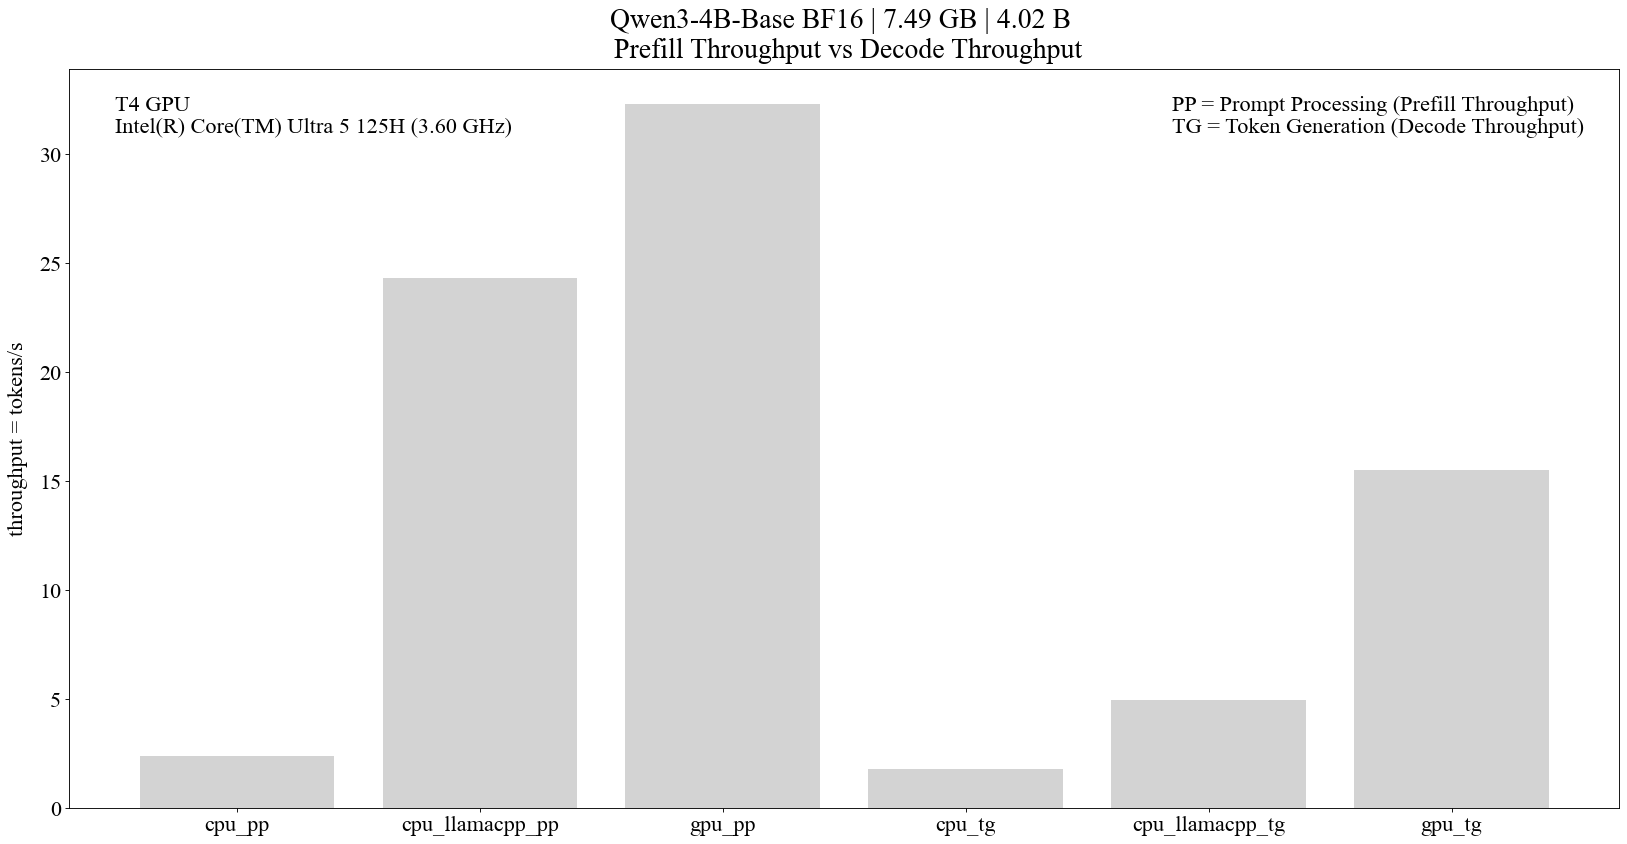

In [28]:
#Estudo que avalia o modelo Qwen 3 4B Base em vários tipos de Hardware -> CPU, CPU com llama.cpp e GPU
#PP -> Prompt Processing
#TP -> Token Processing

QWEN = { #https://github.com/Eliezer-Carvalho
    "cpu_pp": 2.39,
    "cpu_llamacpp_pp": 24.33,
    "gpu_pp": 32.3,

    "cpu_tg": 1.79,
    "cpu_llamacpp_tg": 4.95,
    "gpu_tg": 15.5
}


plt.figure (figsize = (25, 12), dpi = 80)
plt.bar (QWEN.keys(), QWEN.values(), color = "lightgrey")

plt.xticks (size = 20, fontname = "Times New Roman")
plt.yticks (size = 20, fontname = "Times New Roman")

plt.ylabel ("throughput = tokens/s", size = 20, fontname = "Times New Roman", labelpad = 10)

plt.text (-0.5, 32, 'T4 GPU', fontsize = 20, fontname = "Times New Roman")
plt.text (-0.5, 31, 'Intel(R) Core(TM) Ultra 5 125H (3.60 GHz)', fontsize = 20, fontname = "Times New Roman")

plt.text (3.85, 32, 'PP = Prompt Processing (Prefill Throughput)', fontsize = 20, fontname = "Times New Roman")
plt.text (3.85, 31, 'TG = Token Generation (Decode Throughput)', fontsize = 20, fontname = "Times New Roman")

plt.title ("Qwen3-4B-Base BF16 | 7.49 GB | 4.02 B \n Prefill Throughput vs Decode Throughput", size = 25, pad = 10, fontname = "Times New Roman")

plt.show()

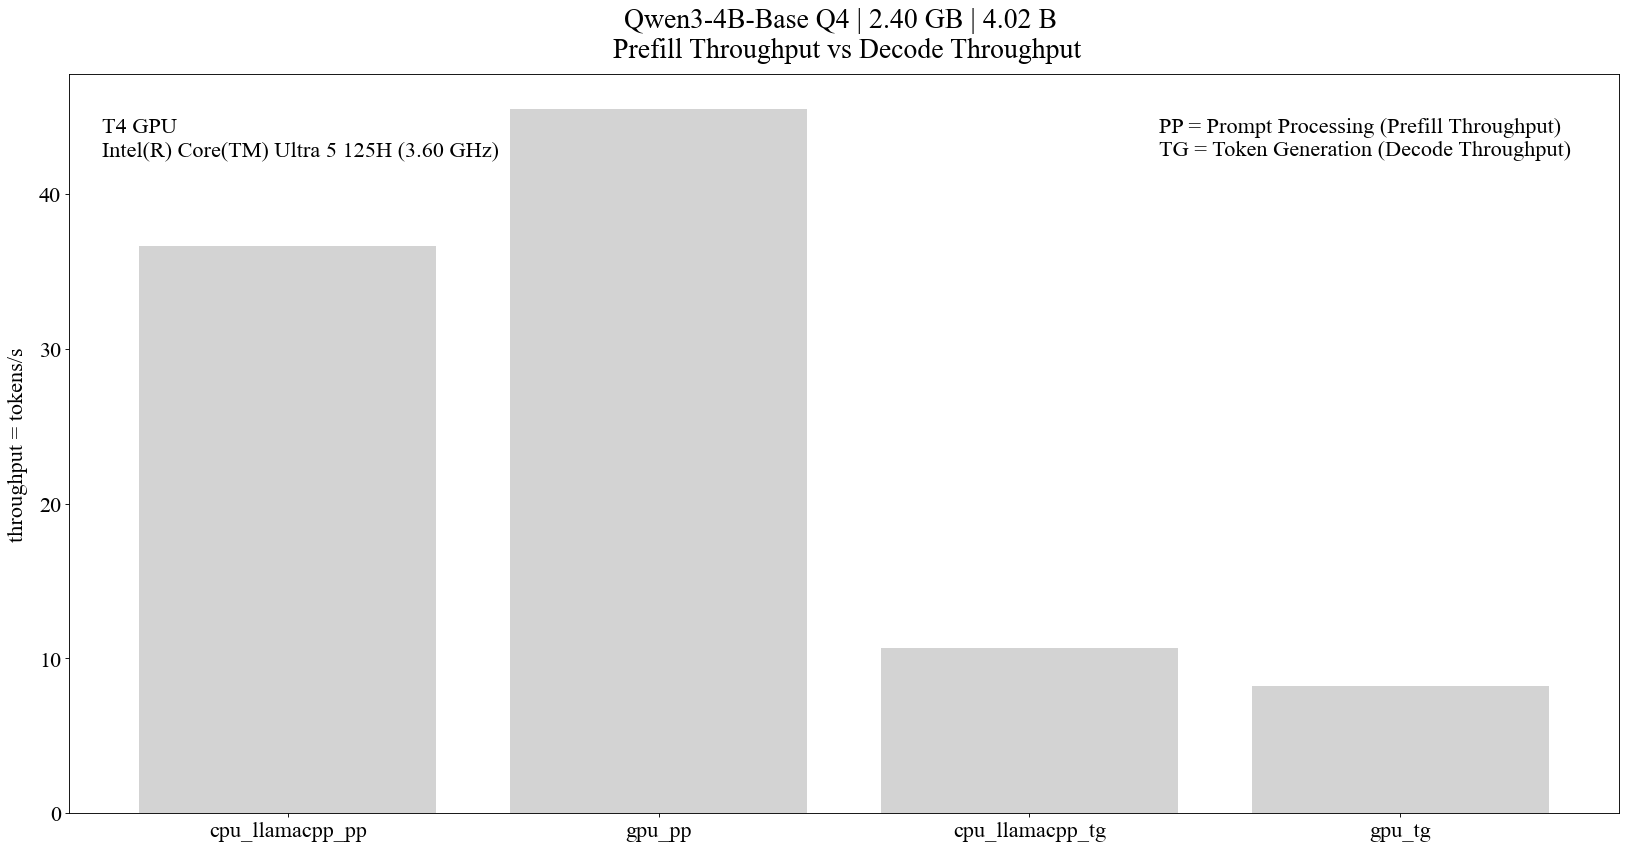

In [36]:
#Estudo que avalia o modelo Qwen 3 4B Base Quantizado a 4 Bits em vários tipos de Hardware -> CPU com llama.cpp e GPU
#PP -> Prompt Processing
#TP -> Token Processing
#Não existe suporte para quantização para modelos C
QWEN_Q4 = { #https://github.com/Eliezer-Carvalho
    "cpu_llamacpp_pp": 36.63,
    "gpu_pp": 45.50,

    "cpu_llamacpp_tg": 10.70,
    "gpu_tg": 8.25
}


plt.figure (figsize = (25, 12), dpi = 80)
plt.bar (QWEN_Q4.keys(), QWEN_Q4.values(), color = "lightgrey")


plt.xticks (size = 20, fontname = "Times New Roman")
plt.yticks (size = 20, fontname = "Times New Roman")

plt.ylabel ("throughput = tokens/s", size = 20, fontname = "Times New Roman", labelpad = 10)

plt.text (-0.5, 44, 'T4 GPU', fontsize = 20, fontname = "Times New Roman")
plt.text (-0.5, 42.5, 'Intel(R) Core(TM) Ultra 5 125H (3.60 GHz)', fontsize = 20, fontname = "Times New Roman")

plt.text (2.35, 44, 'PP = Prompt Processing (Prefill Throughput)', fontsize = 20, fontname = "Times New Roman")
plt.text (2.35, 42.5, 'TG = Token Generation (Decode Throughput)', fontsize = 20, fontname = "Times New Roman")

plt.title ("Qwen3-4B-Base Q4 | 2.40 GB | 4.02 B \n Prefill Throughput vs Decode Throughput", size = 25, pad = 15, fontname = "Times New Roman")
plt.show()

# **Stack**

<b>CPU</b> --> llama.cpp (torch, sentencepiece) | transformers <br>
<b>GPU</b> --> transformers | bitsandbytes <br>